#  Import Libraries

In [2]:
import os
import time
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score,
    precision_score,
    matthews_corrcoef
)

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, MaxPooling1D, Embedding, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import compute_class_weight

# Load Data

In [3]:
df_train = pd.read_csv("KDD_Train_Set.csv")
df_test = pd.read_csv("KDD_Test_Set.csv")
combined_df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

#  Explore Data

In [4]:
headers = list(combined_df.columns.values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}")
print(combined_df.head())
print(len(combined_df))
print("Training data set description: -\n\n")
combined_df.info()
combined_df.describe().T

Headers: -
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

Number of features: 41
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0

,count,mean,std,min,25%,50%,75%,max
duration,148516.0,276.781168,2.460691e+03,0.0,0.00,0.00,0.00,5.771500e+04
src_bytes,148516.0,40228.220158,5.409630e+06,0.0,0.00,44.00,278.00,1.379964e+09
dst_bytes,148516.0,17088.968657,3.703537e+06,0.0,0.00,0.00,571.00,1.309937e+09
land,148516.0,0.000215,1.467719e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,148516.0,0.020523,2.400699e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,148516.0,0.000202,1.941714e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,148516.0,0.189380,2.013167e+00,0.0,0.00,0.00,0.00,1.010000e+02
num_failed_logins,148516.0,0.004323,7.224847e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,148516.0,0.402792,4.904612e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,148516.0,0.255063,2.223145e+01,0.0,0.00,0.00,0.00,7.479000e+03


#  Check Unique Classes and Counts

In [5]:
num_classes  = combined_df['label'].nunique()
class_counts = combined_df['label'].value_counts()
print(f"Number of unique classes: {num_classes}")
print(f"Class counts: {class_counts}")
print(f"Remark total number of data rows is: {combined_df['label'].value_counts().sum()}")

Number of unique classes: 2
Class counts: label
0.0    77053
1.0    71463
Name: count, dtype: int64
Remark total number of data rows is: 148516


#  Null Value Check

In [6]:
null_train_counts = combined_df.isnull().sum().sum()
null_test_counts = combined_df.isnull().any().any()
print(f"Null values in our training data set: {null_train_counts}")
print(f"Does our testing set have any null values? {null_test_counts}")

Null values in our training data set: 0
Does our testing set have any null values? False


#  Data Preprocessing - One-Hot Encoding

In [7]:
combined_df1 = combined_df.copy()

dfDummies = pd.get_dummies(combined_df1["protocol_type"], prefix="protocol", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["protocol_type"], axis=1)

dfDummies = pd.get_dummies(combined_df1["service"], prefix="service", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["service"], axis=1)

dfDummies = pd.get_dummies(combined_df1["flag"], prefix="flag", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["flag"], axis=1)

#  Check Unique Classes and Counts after Preprocessing

In [8]:
num_classes  = combined_df1['label'].nunique()
class_counts = combined_df1['label'].value_counts()
print(f"Number of unique classes: {num_classes}")
print(f"Class counts: {class_counts}")
print(f"Remark total number of data rows is: {combined_df1['label'].value_counts().sum()}")

Number of unique classes: 2
Class counts: label
0.0    77053
1.0    71463
Name: count, dtype: int64
Remark total number of data rows is: 148516


#  Print Columns

In [9]:
print(combined_df1.columns.values)

['duration' 'src_bytes' 'dst_bytes' 'land' 'wrong_fragment' 'urgent' 'hot'
 'num_failed_logins' 'logged_in' 'num_compromised' 'root_shell'
 'su_attempted' 'num_root' 'num_file_creations' 'num_shells'
 'num_access_files' 'num_outbound_cmds' 'is_host_login' 'is_guest_login'
 'count' 'srv_count' 'serror_rate' 'srv_serror_rate' 'rerror_rate'
 'srv_rerror_rate' 'same_srv_rate' 'diff_srv_rate' 'srv_diff_host_rate'
 'dst_host_count' 'dst_host_srv_count' 'dst_host_same_srv_rate'
 'dst_host_diff_srv_rate' 'dst_host_same_src_port_rate'
 'dst_host_srv_diff_host_rate' 'dst_host_serror_rate'
 'dst_host_srv_serror_rate' 'dst_host_rerror_rate'
 'dst_host_srv_rerror_rate' 'label' 'protocol_icmp' 'protocol_tcp'
 'protocol_udp' 'service_IRC' 'service_X11' 'service_Z39_50' 'service_aol'
 'service_auth' 'service_bgp' 'service_courier' 'service_csnet_ns'
 'service_ctf' 'service_daytime' 'service_discard' 'service_domain'
 'service_domain_u' 'service_echo' 'service_eco_i' 'service_ecr_i'
 'service_efs' 'ser

# Data Scaling

In [10]:
y = combined_df1['label']
combined_df1 = combined_df1.drop(columns = 'label', axis = 1)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(combined_df1)
data_scaled = pd.DataFrame(data_scaled, columns=combined_df1.columns)

# Data Splitting

In [11]:
X = data_scaled
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Correlation Graph (Commented Out)

In [12]:
#corr = x_train.corr()
#fig, ax = plt.subplots(figsize = (50, 50))
#sns.heatmap(corr, cmap = 'Blues', annot = True)

#  Print Headers and Number of Features

In [13]:
headers = list(x_train.columns.values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}")

Headers: -
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_icmp', 'protocol_tcp', 'protocol_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'service_echo', 'servic

# Feature Selection based on Correlation

In [14]:
threshold = 0.6
corr_matrix = x_train.corr().abs()
upper_triangle = corr_matrix.where(
    ~np.tril(np.ones(corr_matrix.shape)).astype(bool)
)
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
reduced_x_train = x_train.drop(columns=to_drop)

# Print Headers After Feature Reduction

In [15]:
headers = list(reduced_x_train.columns.values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}")

Headers: -
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'protocol_icmp', 'protocol_tcp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_echo', 'service_efs', 'service_exec', 'service_finger', 'service_ftp_data', 'service_gopher', 'service_harvest', 'service_hostnames', 'service_http_2784', 'service_http_443', 'service_http_8001', 'service_imap4', 'service_iso_tsap', 'service_klogin', 'service_kshell', 'service_ldap', 's

# Check for differences in features between train and test

In [16]:
print(set(reduced_x_train.columns) - set(x_test.columns))
print("=====================================================")
print(set(x_test.columns) - set(reduced_x_train.columns))

set()
{'dst_host_srv_count', 'dst_host_srv_serror_rate', 'srv_rerror_rate', 'is_guest_login', 'protocol_udp', 'flag_REJ', 'flag_S0', 'dst_host_rerror_rate', 'num_root', 'dst_host_srv_rerror_rate', 'flag_SF', 'srv_serror_rate', 'dst_host_serror_rate', 'service_ftp', 'service_ecr_i', 'service_http', 'service_eco_i', 'dst_host_same_srv_rate', 'service_domain_u', 'same_srv_rate'}


# Drop columns from x_test that aren't in x_train (after feature selection)

In [17]:
columns_to_droped = {'dst_host_same_srv_rate', 'flag_SF', 'dst_host_srv_count', 'service_http', 'service_eco_i', 'num_root', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'srv_rerror_rate', 'flag_REJ', 'srv_serror_rate', 'protocol_udp', 'dst_host_srv_rerror_rate', 'service_domain_u', 'service_ecr_i', 'flag_S0', 'service_ftp', 'is_guest_login', 'same_srv_rate', 'dst_host_serror_rate'}
x_test = x_test.drop(columns = columns_to_droped,  errors='ignore')

# Check for differences in features between train and test

In [18]:
print(set(reduced_x_train.columns) - set(x_test.columns))
print("=====================================================")
print(set(x_test.columns) - set(reduced_x_train.columns))

set()
set()


# Model Training and Evaluation

C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activit

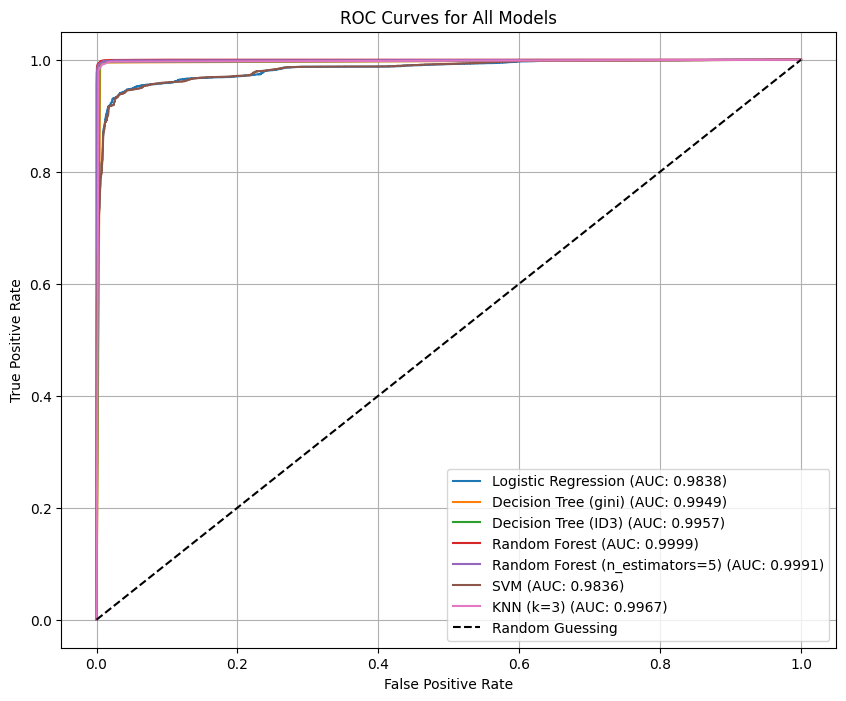

                               Training_Accuracy Testing_Accuracy  \
Logistic Regression                       0.9538           0.9528   
Decision Tree (gini)                      0.9991           0.9939   
Decision Tree (ID3)                       0.9991           0.9948   
Random Forest                             0.9991           0.9955   
Random Forest (n_estimators=5)            0.9986           0.9946   
SVM                                       0.9534           0.9528   
KNN (k=3)                                 0.9953           0.9917   
Neural Network                            0.9889           0.9867   
LSTM                                      0.9894           0.9866   
CNN                                       0.9681           0.9680   

                               Balanced_Accuracy             ROC_AUC F1_Score  \
Logistic Regression                       0.9521  0.9838203916301174   0.9527   
Decision Tree (gini)                      0.9938  0.9949071233550196   0.9939 

In [19]:
evaluation_metrics = [
    "Training_Accuracy", "Testing_Accuracy", "Balanced_Accuracy",
    "ROC_AUC", "F1_Score", "Recall", "Precision", "MCC",
    "Training_time", "Testing_time", "Model_Complexity", "Adaptability", "FOR", "TDR"
]

models = [
    "Logistic Regression", "Decision Tree (gini)", "Decision Tree (ID3)",
    "Random Forest", "Random Forest (n_estimators=5)", "SVM", "KNN (k=3)",
    "Neural Network", "LSTM", "CNN"
]

df = pd.DataFrame(index=models, columns=evaluation_metrics)

model_configs = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Decision Tree (gini)", tree.DecisionTreeClassifier(criterion="gini")),
    ("Decision Tree (ID3)", tree.DecisionTreeClassifier(criterion="entropy")),
    ("Random Forest", RandomForestClassifier()),
    ("Random Forest (n_estimators=5)", RandomForestClassifier(n_estimators=5)),
    ("SVM", LinearSVC(C=1)),
    ("KNN (k=3)", KNeighborsClassifier(n_neighbors=3))
]

plt.figure(figsize=(10, 8))

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)


# Train and evaluate each model
for model_name, model in model_configs:
    # Measure training time and train model
    start_train = time.time()
    model.fit(reduced_x_train, y_train)
    training_time = time.time() - start_train

    # Calculate Training Accuracy
    y_train_pred = model.predict(reduced_x_train)
    training_accuracy = accuracy_score(y_train, y_train_pred)

    # Measure testing time and predict on test set
    start_test = time.time()
    # Get probabilities for ROC if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(x_test)[:, 1]
    else: # Otherwise use decision function for SVM, if available
        if hasattr(model, 'decision_function'):
            y_pred_proba = model.decision_function(x_test)
        else: # Else use predict for other models
            y_pred_proba = model.predict(x_test)
    y_pred = model.predict(x_test)
    testing_time = time.time() - start_test

    # Calculate Testing Metrics
    testing_accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    except ValueError:
        roc_auc = "N/A"
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    # False Omission Rate
    tn = np.sum((y_test == 0) & (y_pred == 0))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    for_ = fn / (tn + fn) if (tn + fn) > 0 else "N/A"

    # Threat Detection Rate (same as recall)
    tp = np.sum((y_test == 1) & (y_pred == 1))
    tdr = tp / (tp + fn) if (tp + fn) > 0 else "N/A"
    
    # Model complexity (approximation, can be further refined)
    if model_name == "Logistic Regression":
        complexity = len(reduced_x_train.columns) # Number of features used
    elif model_name.startswith("Decision Tree"):
        complexity = model.get_depth() # Tree depth
    elif model_name.startswith("Random Forest"):
        complexity = len(model.estimators_) # Number of trees in forest
    elif model_name == "SVM":
        complexity = len(model.coef_[0])
    elif model_name == "KNN (k=3)":
        complexity = 3 # k
    else:
        complexity = "N/A"


    # Adaptability (Placeholder, requires more in-depth techniques to measure)
    adaptability = "Low"  # Placeholder for now, as true adaptability assessment is quite complex

    # ROC Curve for ML Models Only
    try:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC: {roc_auc:.4f})")
    except ValueError:
        print(f"ROC Curve could not be computed for {model_name}.")


    # Store results in DataFrame
    df.loc[model_name] = [
        f"{training_accuracy:.4f}", f"{testing_accuracy:.4f}", f"{balanced_accuracy:.4f}",
        f"{roc_auc}" if roc_auc != "N/A" else "N/A", f"{f1:.4f}",
        f"{recall:.4f}", f"{precision:.4f}", f"{mcc:.4f}",
        f"{training_time:.4f}s", f"{testing_time:.4f}s", f"{complexity}", f"{adaptability}", f"{for_}", f"{tdr}"
    ]


# Neural Network model
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(reduced_x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')  # Output layer
])

nn_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_train = time.time()
nn_model.fit(reduced_x_train, y_train_categorical, epochs=10, verbose=0)
training_time = time.time() - start_train

y_train_pred_nn = np.argmax(nn_model.predict(reduced_x_train, verbose=0), axis=-1)
training_accuracy = accuracy_score(y_train_encoded, y_train_pred_nn)

start_test = time.time()
y_pred_nn_proba = nn_model.predict(x_test, verbose=0)
y_pred_nn = np.argmax(y_pred_nn_proba, axis=-1)
testing_time = time.time() - start_test

testing_accuracy = accuracy_score(y_test_encoded, y_pred_nn)
balanced_accuracy = balanced_accuracy_score(y_test_encoded, y_pred_nn)
try:
    roc_auc = roc_auc_score(y_test_encoded, y_pred_nn_proba, multi_class='ovr', average='weighted')
except ValueError:
    roc_auc = "N/A"
f1 = f1_score(y_test_encoded, y_pred_nn, average='weighted')
recall = recall_score(y_test_encoded, y_pred_nn, average='weighted')
precision = precision_score(y_test_encoded, y_pred_nn, average='weighted')
mcc = matthews_corrcoef(y_test_encoded, y_pred_nn)

# False Omission Rate
tn = np.sum((y_test_encoded == 0) & (y_pred_nn == 0))
fn = np.sum((y_test_encoded == 1) & (y_pred_nn == 0))
for_ = fn / (tn + fn) if (tn + fn) > 0 else "N/A"

# Threat Detection Rate (same as recall)
tp = np.sum((y_test_encoded == 1) & (y_pred_nn == 1))
tdr = tp / (tp + fn) if (tp + fn) > 0 else "N/A"

# Model complexity (approximation, can be further refined)
complexity = nn_model.count_params() # Total number of trainable parameters
# Adaptability (Placeholder, requires more in-depth techniques to measure)
adaptability = "Medium" # Placeholder for now

df.loc["Neural Network"] = [
    f"{training_accuracy:.4f}", f"{testing_accuracy:.4f}", f"{balanced_accuracy:.4f}",
    f"{roc_auc}" if roc_auc != "N/A" else "N/A", f"{f1:.4f}",
    f"{recall:.4f}", f"{precision:.4f}", f"{mcc:.4f}",
    f"{training_time:.4f}s", f"{testing_time:.4f}s", f"{complexity}", f"{adaptability}", f"{for_}", f"{tdr}"
]

# LSTM Model
# Reshape the data for LSTM
x_train_lstm = reduced_x_train.values.reshape((reduced_x_train.shape[0], 1, reduced_x_train.shape[1]))
x_test_lstm = x_test.values.reshape((x_test.shape[0], 1, x_test.shape[1]))

# LSTM Model
lstm_model = Sequential([
    LSTM(64, input_shape=(x_train_lstm.shape[1], x_train_lstm.shape[2])),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_train = time.time()
lstm_model.fit(x_train_lstm, y_train_categorical, epochs=10, verbose=0)
training_time = time.time() - start_train


y_train_pred_lstm = np.argmax(lstm_model.predict(x_train_lstm, verbose=0), axis=-1)
training_accuracy = accuracy_score(y_train_encoded, y_train_pred_lstm)


start_test = time.time()
y_pred_lstm_proba = lstm_model.predict(x_test_lstm, verbose=0)
y_pred_lstm = np.argmax(y_pred_lstm_proba, axis=-1)
testing_time = time.time() - start_test


testing_accuracy = accuracy_score(y_test_encoded, y_pred_lstm)
balanced_accuracy = balanced_accuracy_score(y_test_encoded, y_pred_lstm)
try:
    roc_auc = roc_auc_score(y_test_encoded, y_pred_lstm_proba, multi_class='ovr', average='weighted')
except ValueError:
    roc_auc = "N/A"
f1 = f1_score(y_test_encoded, y_pred_lstm, average='weighted')
recall = recall_score(y_test_encoded, y_pred_lstm, average='weighted')
precision = precision_score(y_test_encoded, y_pred_lstm, average='weighted')
mcc = matthews_corrcoef(y_test_encoded, y_pred_lstm)

# False Omission Rate
tn = np.sum((y_test_encoded == 0) & (y_pred_lstm == 0))
fn = np.sum((y_test_encoded == 1) & (y_pred_lstm == 0))
for_ = fn / (tn + fn) if (tn + fn) > 0 else "N/A"

# Threat Detection Rate (same as recall)
tp = np.sum((y_test_encoded == 1) & (y_pred_lstm == 1))
tdr = tp / (tp + fn) if (tp + fn) > 0 else "N/A"

# Model complexity (approximation, can be further refined)
complexity = lstm_model.count_params() # Total number of trainable parameters
# Adaptability (Placeholder, requires more in-depth techniques to measure)
adaptability = "Medium" # Placeholder for now

df.loc["LSTM"] = [
    f"{training_accuracy:.4f}", f"{testing_accuracy:.4f}", f"{balanced_accuracy:.4f}",
    f"{roc_auc}" if roc_auc != "N/A" else "N/A", f"{f1:.4f}",
    f"{recall:.4f}", f"{precision:.4f}", f"{mcc:.4f}",
    f"{training_time:.4f}s", f"{testing_time:.4f}s", f"{complexity}", f"{adaptability}", f"{for_}", f"{tdr}"
]

# CNN Model
# Reshape data for CNN
x_train_cnn = reduced_x_train.values.reshape((reduced_x_train.shape[0], reduced_x_train.shape[1], 1))
x_test_cnn = x_test.values.reshape((x_test.shape[0], x_test.shape[1], 1))

# CNN model
cnn_model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(x_train_cnn.shape[1], 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_train = time.time()
cnn_model.fit(x_train_cnn, y_train_categorical, epochs=10, verbose=0)
training_time = time.time() - start_train

y_train_pred_cnn = np.argmax(cnn_model.predict(x_train_cnn, verbose=0), axis=-1)
training_accuracy = accuracy_score(y_train_encoded, y_train_pred_cnn)

start_test = time.time()
y_pred_cnn_proba = cnn_model.predict(x_test_cnn, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_proba, axis=-1)
testing_time = time.time() - start_test


testing_accuracy = accuracy_score(y_test_encoded, y_pred_cnn)
balanced_accuracy = balanced_accuracy_score(y_test_encoded, y_pred_cnn)
try:
    roc_auc = roc_auc_score(y_test_encoded, y_pred_cnn_proba, multi_class='ovr', average='weighted')
except ValueError:
    roc_auc = "N/A"
f1 = f1_score(y_test_encoded, y_pred_cnn, average='weighted')
recall = recall_score(y_test_encoded, y_pred_cnn, average='weighted')
precision = precision_score(y_test_encoded, y_pred_cnn, average='weighted')
mcc = matthews_corrcoef(y_test_encoded, y_pred_cnn)

# False Omission Rate
tn = np.sum((y_test_encoded == 0) & (y_pred_cnn == 0))
fn = np.sum((y_test_encoded == 1) & (y_pred_cnn == 0))
for_ = fn / (tn + fn) if (tn + fn) > 0 else "N/A"

# Threat Detection Rate (same as recall)
tp = np.sum((y_test_encoded == 1) & (y_pred_cnn == 1))
tdr = tp / (tp + fn) if (tp + fn) > 0 else "N/A"

# Model complexity (approximation, can be further refined)
complexity = cnn_model.count_params() # Total number of trainable parameters
# Adaptability (Placeholder, requires more in-depth techniques to measure)
adaptability = "Medium" # Placeholder for now

df.loc["CNN"] = [
    f"{training_accuracy:.4f}", f"{testing_accuracy:.4f}", f"{balanced_accuracy:.4f}",
        f"{roc_auc}" if roc_auc != "N/A" else "N/A", f"{f1:.4f}",
        f"{recall:.4f}", f"{precision:.4f}", f"{mcc:.4f}",
        f"{training_time:.4f}s", f"{testing_time:.4f}s", f"{complexity}", f"{adaptability}", f"{for_}", f"{tdr}"
]



# Finalize the ROC Curve plot
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid()
plt.savefig("roc_curves_all_models.png")  # Save the plot
plt.show()

# Save metrics to Excel
df.to_excel("model_evaluation_metrics.xlsx")

# Print DataFrame
print(df)

# Save Scaled Dataframes

In [20]:
x_train_scaled_df = pd.DataFrame(reduced_x_train, columns=reduced_x_train.columns)
x_train_scaled_df['label'] = y_train
x_train_scaled_df.to_csv(r'KDD_Train_Set2.csv', index=False)

x_test_scaled_df = pd.DataFrame(x_test, columns=x_test.columns)
x_test_scaled_df['label'] = y_test
x_test_scaled_df.to_csv(r'KDD_Test_Set2.csv', index=False)